# Task 4 — Trend Prediction Analysis

## Netflix Content Trend Forecasting

### Objective

The objective of this task is to analyze historical Netflix content trends by release year and forecast future content growth.

The analysis will examine yearly content patterns, develop a forecasting model, evaluate its performance, and visualize projected future trends.

### Workflow

1. Prepare release-year data
2. Analyze yearly content trends
3. Build a forecasting model
4. Visualize future predictions
5. Evaluate and interpret the results

### Tools & Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/netflix_cleaned.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (8790, 14)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,added_year,added_month,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90,min
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1,Season
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,1,Season
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,91,min
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,125,min


In [3]:
yearly_content = (
    df.groupby("release_year")
      .size()
      .reset_index(name="content_count")
      .sort_values("release_year")
)

yearly_content.head()

,release_year,content_count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,4


In [4]:
print("First Release Year:", yearly_content["release_year"].min())
print("Latest Release Year:", yearly_content["release_year"].max())
print("Number of Years:", yearly_content.shape[0])

First Release Year: 1925
Latest Release Year: 2021
Number of Years: 74


In [5]:
yearly_content.tail(10)

,release_year,content_count
64,2012,236
65,2013,286
66,2014,352
67,2015,555
68,2016,901
69,2017,1030
70,2018,1146
71,2019,1030
72,2020,953
73,2021,592


In [6]:
yearly_content["content_count"].describe()

count      74.000000
mean      118.783784
std       266.657148
min         1.000000
25%         3.000000
50%        12.500000
75%        57.000000
max      1146.000000
Name: content_count, dtype: float64

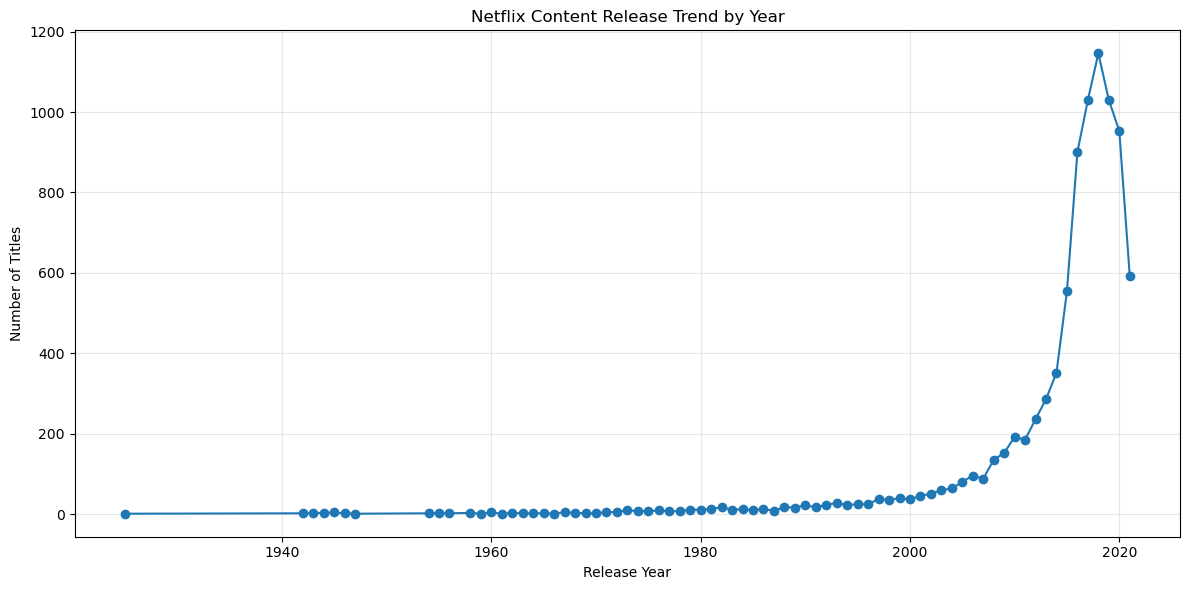

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_content["release_year"],
    yearly_content["content_count"],
    marker="o"
)

plt.title("Netflix Content Release Trend by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../outputs/task_4_yearly_content_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
recent_trend = yearly_content[
    yearly_content["release_year"] >= 2010
].copy()

recent_trend

,release_year,content_count
62,2010,192
63,2011,185
64,2012,236
65,2013,286
66,2014,352
67,2015,555
68,2016,901
69,2017,1030
70,2018,1146
71,2019,1030


In [9]:
recent_trend["yearly_growth_pct"] = (
    recent_trend["content_count"]
    .pct_change() * 100
)

recent_trend.tail(10)

,release_year,content_count,yearly_growth_pct
64,2012,236,27.567568
65,2013,286,21.186441
66,2014,352,23.076923
67,2015,555,57.670455
68,2016,901,62.342342
69,2017,1030,14.317425
70,2018,1146,11.262136
71,2019,1030,-10.122164
72,2020,953,-7.475728
73,2021,592,-37.880378


In [10]:
peak_year = yearly_content.loc[
    yearly_content["content_count"].idxmax()
]

print("Peak Release Year:", peak_year["release_year"])
print("Peak Content Count:", peak_year["content_count"])

Peak Release Year: 2018
Peak Content Count: 1146


In [11]:
recent_summary = recent_trend[
    recent_trend["release_year"] >= 2015
]

print(
    "2015 Content:",
    int(recent_summary.loc[
        recent_summary["release_year"] == 2015,
        "content_count"
    ].iloc[0])
)

print(
    "2021 Content:",
    int(recent_summary.loc[
        recent_summary["release_year"] == 2021,
        "content_count"
    ].iloc[0])
)

print(
    "Peak Year:",
    int(peak_year["release_year"])
)

2015 Content: 555
2021 Content: 592
Peak Year: 2018


In [12]:
forecast_data = yearly_content[
    yearly_content["release_year"] >= 2010
].copy()

X = forecast_data[["release_year"]]
y = forecast_data["content_count"]

print("Forecasting Period:", 
      forecast_data["release_year"].min(),
      "to",
      forecast_data["release_year"].max())

print("Training Records:", len(forecast_data))

Forecasting Period: 2010 to 2021
Training Records: 12


In [13]:
train_data = forecast_data.iloc[:-3]
test_data = forecast_data.iloc[-3:]

X_train = train_data[["release_year"]]
y_train = train_data["content_count"]

X_test = test_data[["release_year"]]
y_test = test_data["content_count"]

print("Training Years:", train_data["release_year"].min(), 
      "-", train_data["release_year"].max())

print("Testing Years:", test_data["release_year"].min(), 
      "-", test_data["release_year"].max())

Training Years: 2010 - 2018
Testing Years: 2019 - 2021


In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Coefficient:", model.coef_[0])
print("Model Intercept:", model.intercept_)

Model Coefficient: 132.50000000000003
Model Intercept: -266312.4444444445


In [15]:
y_pred = model.predict(X_test)

test_results = test_data.copy()

test_results["predicted_count"] = y_pred.round(0).astype(int)

test_results

,release_year,content_count,predicted_count
71,2019,1030,1205
72,2020,953,1338
73,2021,592,1470


In [16]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 479.22
RMSE: 562.59


In [17]:
future_years = pd.DataFrame({
    "release_year": range(2022, 2027)
})

future_predictions = model.predict(
    future_years[["release_year"]]
)

future_forecast = future_years.copy()

future_forecast["predicted_count"] = (
    future_predictions.round(0).astype(int)
)

future_forecast

,release_year,predicted_count
0,2022,1603
1,2023,1735
2,2024,1868
3,2025,2000
4,2026,2133


In [18]:
historical_plot = yearly_content[
    yearly_content["release_year"] >= 2010
][["release_year", "content_count"]].copy()

historical_plot["data_type"] = "Historical"

forecast_plot = future_forecast.rename(
    columns={"predicted_count": "content_count"}
)

forecast_plot["data_type"] = "Forecast"

combined_forecast = pd.concat(
    [
        historical_plot,
        forecast_plot
    ],
    ignore_index=True
)

combined_forecast.tail(10)

,release_year,content_count,data_type
7,2017,1030,Historical
8,2018,1146,Historical
9,2019,1030,Historical
10,2020,953,Historical
11,2021,592,Historical
12,2022,1603,Forecast
13,2023,1735,Forecast
14,2024,1868,Forecast
15,2025,2000,Forecast
16,2026,2133,Forecast


In [19]:
future_forecast.to_csv(
    "../outputs/task_4_future_forecast.csv",
    index=False
)

print("Saved:", "../outputs/task_4_future_forecast.csv")

Saved: ../outputs/task_4_future_forecast.csv


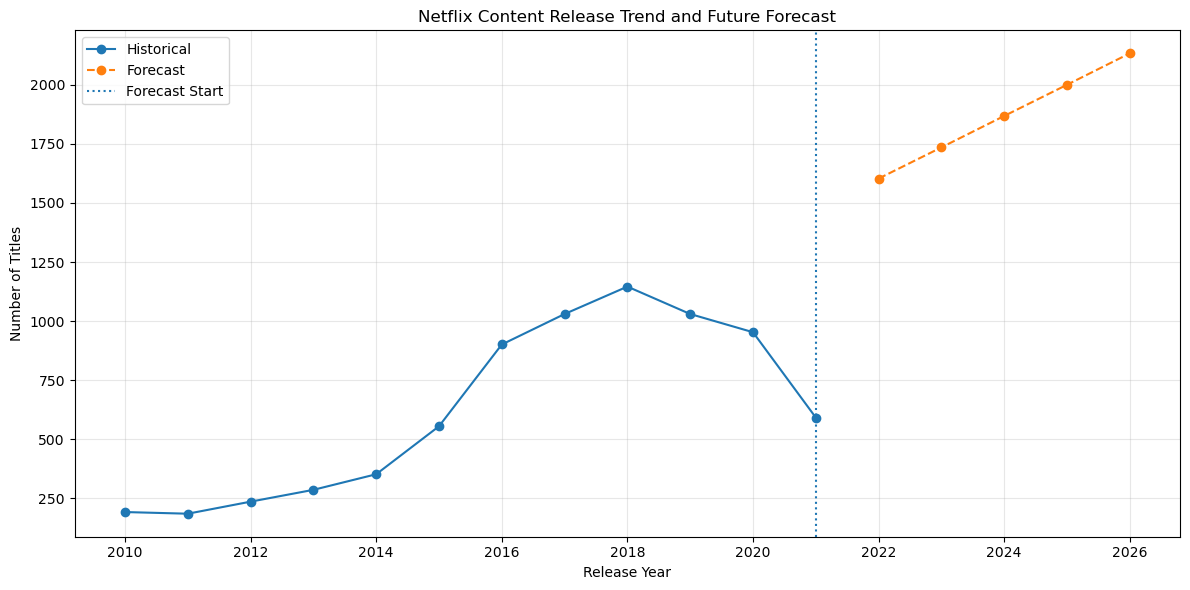

In [20]:
plt.figure(figsize=(12, 6))

historical_data = combined_forecast[
    combined_forecast["data_type"] == "Historical"
]

forecast_data = combined_forecast[
    combined_forecast["data_type"] == "Forecast"
]

plt.plot(
    historical_data["release_year"],
    historical_data["content_count"],
    marker="o",
    label="Historical"
)

plt.plot(
    forecast_data["release_year"],
    forecast_data["content_count"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.axvline(
    x=2021,
    linestyle=":",
    label="Forecast Start"
)

plt.title("Netflix Content Release Trend and Future Forecast")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig(
    "../outputs/task_4_historical_vs_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
future_forecast

,release_year,predicted_count
0,2022,1603
1,2023,1735
2,2024,1868
3,2025,2000
4,2026,2133


In [22]:
mape = (
    np.mean(
        np.abs(
            (y_test - y_pred) / y_test
        )
    ) * 100
)

print(f"MAPE: {mape:.2f}%")

MAPE: 68.56%


## Task 4 — Results, Evaluation & Interpretation

### Historical Trend

The analysis covered Netflix content released between 1925 and 2021, with 74 distinct release years.

Recent content production showed substantial growth between 2015 and 2018. The number of titles increased from 555 in 2015 to a peak of 1,146 titles in 2018.

After 2018, the observed content count declined:

- 2019: 1,030 titles
- 2020: 953 titles
- 2021: 592 titles

The largest recent year-over-year increase occurred in 2016, with approximately 62.34% growth compared with 2015. The largest recent decline occurred in 2021, with approximately 37.88% decline compared with 2020.

### Forecasting Model

A Linear Regression model was developed using release-year data from 2010 to 2021.

The data was divided into:

- Training period: 2010–2018
- Testing period: 2019–2021

### Model Evaluation

The model produced the following evaluation results:

| Metric | Result |
|---|---:|
| MAE | 479.22 |
| RMSE | 562.59 |
| MAPE | 68.56% |

The relatively high error values indicate that the linear regression model does not accurately capture the changing pattern in the recent Netflix content trend.

For example, the model predicted increasing content counts for 2019–2021, while the actual data showed a decline during this period.

### Future Forecast

Based on the fitted linear trend, the model generated the following projections:

| Year | Predicted Content Count |
|---|---:|
| 2022 | 1,603 |
| 2023 | 1,735 |
| 2024 | 1,868 |
| 2025 | 2,000 |
| 2026 | 2,133 |

These values represent model-based projections rather than actual Netflix content counts.

### Interpretation

The historical data shows that Netflix content growth was strong during the mid-to-late 2010s, reaching a peak in 2018. The subsequent decline demonstrates that the relationship between release year and content volume is not consistently linear.

The linear regression model extrapolates the earlier upward trend and therefore overestimates future content counts after the observed decline.

### Limitations

The forecasting model has several limitations:

1. Linear Regression assumes a relatively consistent linear relationship between year and content count.
2. Only 12 annual observations from 2010–2021 were used for forecasting.
3. The dataset contains historical Netflix catalog information rather than a continuously updated production dataset.
4. External factors affecting content production are not included.
5. The high MAE, RMSE, and MAPE indicate limited predictive accuracy.

### Conclusion

The trend analysis successfully identified major historical changes in Netflix content volume and demonstrated an end-to-end forecasting workflow.

Although the Linear Regression baseline produced future projections, its evaluation metrics indicate that a more advanced time-series forecasting approach would be more appropriate for capturing nonlinear trends and changing growth patterns.